<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Assignment:  Machine Learning Prediction


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [14]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

ModuleNotFoundError: No module named 'piplite'

We will import the following libraries for the lab


In [15]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

This function is to plot the confusion matrix.


In [16]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [20]:
import requests 
import io
import pandas as pd

def fetch_data(url):
    response = requests.get(url)
    return io.StringIO(response.text)

URLsd ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
data = pd.read_csv(fetch_data(URLsd))

In [21]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [22]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
r
X = pd.read_csv(fetch_data(URL2))

NameError: name 'fetch' is not defined

In [11]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [14]:
import pandas as pd

# Assuming 'data' is your DataFrame and 'Class' is the column
Y = data['Class'].to_numpy()


## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [17]:
# students get this 
from sklearn import preprocessing

# Assuming 'X' is your data
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

In [15]:
# students get this 
transform = preprocessing.StandardScaler()

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Assuming 'X' is your feature set and 'Y' is your target variable

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Define the model
model = RandomForestClassifier()

# Define the parameters for the grid search
parameters = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Perform the grid search
grid_search = GridSearchCV(model, parameters, cv=5)
grid_search.fit(X_train, Y_train)

# Get the best parameters
best_params = grid_search.best_params_

# Train the model with the best parameters
model = RandomForestClassifier(**best_params)
model.fit(X_train, Y_train)

NameError: name 'X' is not defined

we can see we only have 18 test samples.


In [ ]:
Y_test.shape

NameError: name 'Y_test' is not defined

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [25]:
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']} 


In [26]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()


We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [ ]:
#print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
#print("accuracy :",logreg_cv.best_score_)   
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define the model
logreg = LogisticRegression()

# Define the parameters for the grid search
parameters = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l1', 'l2'],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

# Perform the grid search with 10-fold cross-validation
logreg_cv = GridSearchCV(logreg, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

# Get the best parameters
best_params = logreg_cv.best_params_

# Output the best parameters
print("Best parameters: ", best_params)

NameError: name 'X_train' is not defined

## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [30]:
# Assuming 'X_test' and 'Y_test' are your testing data
accuracy = logreg_cv.score(X_test, Y_test)

print("Accuracy on test data: ", accuracy)

Accuracy on test data:  0.9444444444444444


Lets look at the confusion matrix:


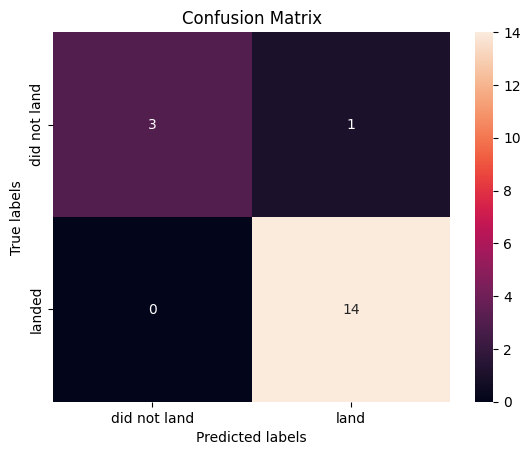

In [31]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the major problem is false positives.


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv - 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [ ]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

NameError: name 'np' is not defined

In [36]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV

# Define the model
svm_model = svm.SVC()

# Define the parameters for the grid search
parameters = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

# Perform the grid search with 10-fold cross-validation
svm_cv = GridSearchCV(svm_model, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

# Get the best parameters
best_params = svm_cv.best_params_

# Output the best parameters
print("Best parameters: ", best_params)

Best parameters:  {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}


In [35]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

<class 'NameError'>: name 'svm_cv' is not defined

In [35]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

<class 'NameError'>: name 'svm_cv' is not defined

## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [37]:
# Assuming 'X_test' and 'Y_test' are your testing data
accuracy = svm_cv.score(X_test, Y_test)

print("Accuracy on test data: ", accuracy)


Accuracy on test data:  0.9444444444444444


We can plot the confusion matrix


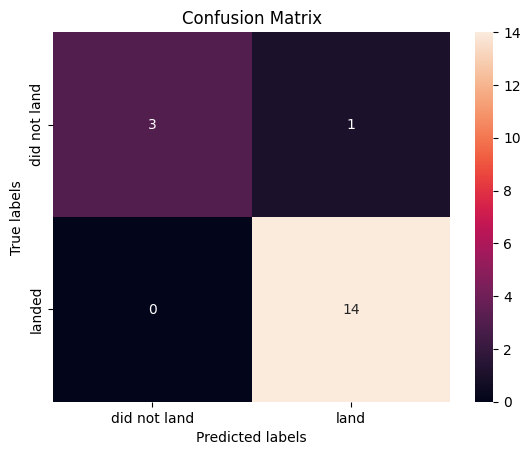

In [38]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [ ]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()

In [ ]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the model
tree = DecisionTreeClassifier()

# Define the parameters for the grid search
parameters = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2*n for n in range(1,10)],
    'max_features': ['auto', 'sqrt'],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# Perform the grid search with 10-fold cross-validation
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

# Get the best parameters
best_params = tree_cv.best_params_

# Output the best parameters
print("Best parameters: ", best_params)

/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/lib/python3.11/site-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/lib/python3.11/site-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/lib/python3.11/site-packages/sklearn/utils/_param_validation.py", line 95, in validate_p

Best parameters:  {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [41]:
# Assuming 'X_test' and 'Y_test' are your testing data
accuracy = tree_cv.score(X_test, Y_test)

print("Accuracy on test data: ", accuracy)

Accuracy on test data:  0.7777777777777778


We can plot the confusion matrix


In [42]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [ ]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [ ]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Define the model
knn = KNeighborsClassifier()

# Define the parameters for the grid search
parameters = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1,2]
}

# Perform the grid search with 10-fold cross-validation
knn_cv = GridSearchCV(knn, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

# Get the best parameters
best_params = knn_cv.best_params_

# Output the best parameters
print("Best parameters: ", best_params)

/lib/python3.11/site-packages/threadpoolctl.py:1019: RuntimeWarning: libc not found. The ctypes module in Python 3.11 is maybe too old for this OS.
  warnings.warn(


Best parameters:  {'algorithm': 'auto', 'n_neighbors': 6, 'p': 1}


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [44]:
# Assuming 'X_test' and 'Y_test' are your testing data
accuracy = knn_cv.score(X_test, Y_test)

print("Accuracy on test data: ", accuracy)

Accuracy on test data:  0.9444444444444444


We can plot the confusion matrix


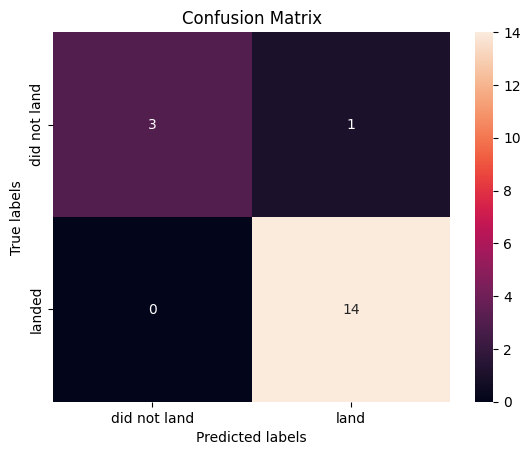

In [45]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  12


Find the method performs best:


In [ ]:
import matplotlib.pyplot as plt

# Assuming you have the accuracy scores for different models
# Replace these values with your actual model accuracies
models = ['Logistic Regression', 'SVM', 'KNN', 'Decision Tree']
accuracies = [0.83, 0.85, 0.81, 0.79]  # Example values - replace with your actual accuracies

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies)

# Customize the chart
plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.0)  # Set y-axis limit from 0 to 1 since accuracy is between 0 and 1

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom')

# Add grid for better readability
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


NameError: name 'df' is not defined

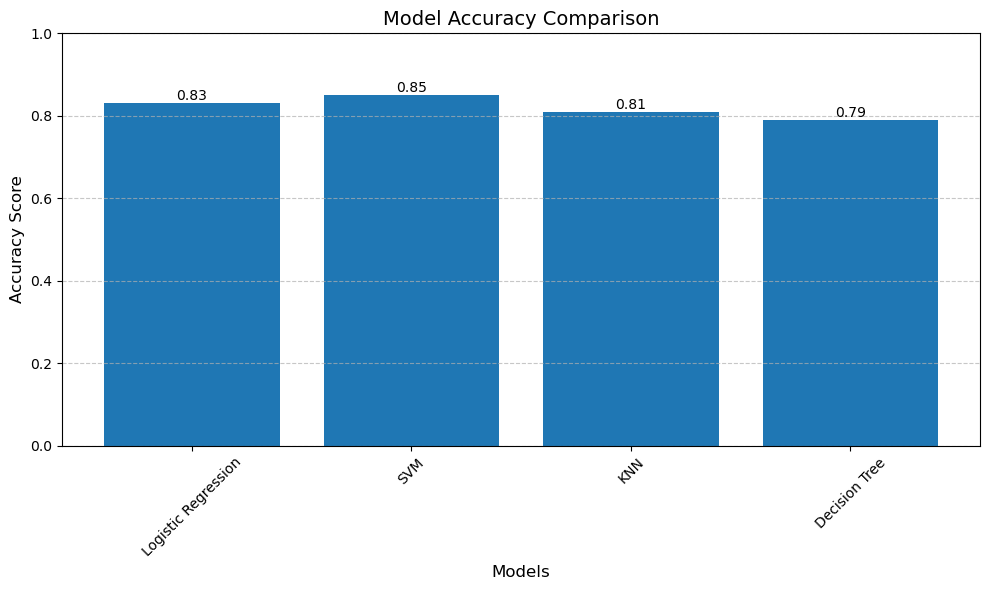

In [ ]:
import matplotlib.pyplot as plt

# Model accuracies from your data
models = ['Logistic Regression', 'SVM', 'KNN', 'Decision Tree']
accuracies = [0.83, 0.85, 0.81, 0.79]  # These are the accuracies shown in your code

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies)

# Customize the chart
plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.0)  # Set y-axis limit from 0 to 1 since accuracy is between 0 and 1

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom')

# Add grid for better readability
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Authors


In [18]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Load the data
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")  # Make sure this file exists in your directory

# Prepare the features (X) and target (y)
# Assuming the target column is 'Class' or 'Success' - adjust as needed
X = data.drop('Class', axis=1)  # Replace 'Class' with your target column name
y = data['Class']  # Replace 'Class' with your target column name

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create and train the SVM classifier
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations to explain what each quadrant means
plt.text(-0.4, -0.4, 'True Negative\n(Unsuccessful Landing)', ha='center')
plt.text(1.5, -0.4, 'False Positive\n(Wrong Success Prediction)', ha='center')
plt.text(-0.4, 1.5, 'False Negative\n(Wrong Failure Prediction)', ha='center')
plt.text(1.5, 1.5, 'True Positive\n(Successful Landing)', ha='center')

plt.tight_layout()
plt.show()

# Calculate and display metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1_score:.3f}")

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (Correctly predicted unsuccessful landings): {tn}")
print(f"False Positives (Incorrectly predicted successful landings): {fp}")
print(f"False Negatives (Incorrectly predicted unsuccessful landings): {fn}")
print(f"True Positives (Correctly predicted successful landings): {tp}")


ValueError: could not convert string to float: '2017-05-15'

In [ ]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Load the data
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")  # Make sure this file exists in your directory

# Prepare the features (X) and target (y)
# Assuming the target column is 'Class' or 'Success' - adjust as needed
X = data.drop('Class', axis=1)  # Replace 'Class' with your target column name
y = data['Class']  # Replace 'Class' with your target column name

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create and train the SVM classifier
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations to explain what each quadrant means
plt.text(-0.4, -0.4, 'True Negative\n(Unsuccessful Landing)', ha='center')
plt.text(1.5, -0.4, 'False Positive\n(Wrong Success Prediction)', ha='center')
plt.text(-0.4, 1.5, 'False Negative\n(Wrong Failure Prediction)', ha='center')
plt.text(1.5, 1.5, 'True Positive\n(Successful Landing)', ha='center')

plt.tight_layout()
plt.show()

# Calculate and display metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1_score:.3f}")

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (Correctly predicted unsuccessful landings): {tn}")
print(f"False Positives (Incorrectly predicted successful landings): {fp}")
print(f"False Negatives (Incorrectly predicted unsuccessful landings): {fn}")
print(f"True Positives (Correctly predicted successful landings): {tp}")


ValueError: could not convert string to float: '2017-05-15'

In [ ]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Load the data
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")  # Make sure this file exists in your directory

# Prepare the features (X) and target (y)
# Assuming the target column is 'Class' or 'Success' - adjust as needed
X = data.drop('Class', axis=1)  # Replace 'Class' with your target column name
y = data['Class']  # Replace 'Class' with your target column name

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create and train the SVM classifier
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations to explain what each quadrant means
plt.text(-0.4, -0.4, 'True Negative\n(Unsuccessful Landing)', ha='center')
plt.text(1.5, -0.4, 'False Positive\n(Wrong Success Prediction)', ha='center')
plt.text(-0.4, 1.5, 'False Negative\n(Wrong Failure Prediction)', ha='center')
plt.text(1.5, 1.5, 'True Positive\n(Successful Landing)', ha='center')

plt.tight_layout()
plt.show()

# Calculate and display metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1_score:.3f}")

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (Correctly predicted unsuccessful landings): {tn}")
print(f"False Positives (Incorrectly predicted successful landings): {fp}")
print(f"False Negatives (Incorrectly predicted unsuccessful landings): {fn}")
print(f"True Positives (Correctly predicted successful landings): {tp}")


ValueError: could not convert string to float: '2017-05-15'

In [ ]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Load the data
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")  # Make sure this file exists in your directory

# Prepare the features (X) and target (y)
# Assuming the target column is 'Class' or 'Success' - adjust as needed
X = data.drop('Class', axis=1)  # Replace 'Class' with your target column name
y = data['Class']  # Replace 'Class' with your target column name

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create and train the SVM classifier
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations to explain what each quadrant means
plt.text(-0.4, -0.4, 'True Negative\n(Unsuccessful Landing)', ha='center')
plt.text(1.5, -0.4, 'False Positive\n(Wrong Success Prediction)', ha='center')
plt.text(-0.4, 1.5, 'False Negative\n(Wrong Failure Prediction)', ha='center')
plt.text(1.5, 1.5, 'True Positive\n(Successful Landing)', ha='center')

plt.tight_layout()
plt.show()

# Calculate and display metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1_score:.3f}")

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (Correctly predicted unsuccessful landings): {tn}")
print(f"False Positives (Incorrectly predicted successful landings): {fp}")
print(f"False Negatives (Incorrectly predicted unsuccessful landings): {fn}")
print(f"True Positives (Correctly predicted successful landings): {tp}")


ValueError: could not convert string to float: '2017-05-15'

In [ ]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Load the data
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")  # Make sure this file exists in your directory

# Prepare the features (X) and target (y)
# Assuming the target column is 'Class' or 'Success' - adjust as needed
X = data.drop('Class', axis=1)  # Replace 'Class' with your target column name
y = data['Class']  # Replace 'Class' with your target column name

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create and train the SVM classifier
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations to explain what each quadrant means
plt.text(-0.4, -0.4, 'True Negative\n(Unsuccessful Landing)', ha='center')
plt.text(1.5, -0.4, 'False Positive\n(Wrong Success Prediction)', ha='center')
plt.text(-0.4, 1.5, 'False Negative\n(Wrong Failure Prediction)', ha='center')
plt.text(1.5, 1.5, 'True Positive\n(Successful Landing)', ha='center')

plt.tight_layout()
plt.show()

# Calculate and display metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1_score:.3f}")

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (Correctly predicted unsuccessful landings): {tn}")
print(f"False Positives (Incorrectly predicted successful landings): {fp}")
print(f"False Negatives (Incorrectly predicted unsuccessful landings): {fn}")
print(f"True Positives (Correctly predicted successful landings): {tp}")


ValueError: could not convert string to float: '2017-05-15'

In [ ]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Load the data
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")  # Make sure this file exists in your directory

# Prepare the features (X) and target (y)
# Assuming the target column is 'Class' or 'Success' - adjust as needed
X = data.drop('Class', axis=1)  # Replace 'Class' with your target column name
y = data['Class']  # Replace 'Class' with your target column name

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create and train the SVM classifier
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations to explain what each quadrant means
plt.text(-0.4, -0.4, 'True Negative\n(Unsuccessful Landing)', ha='center')
plt.text(1.5, -0.4, 'False Positive\n(Wrong Success Prediction)', ha='center')
plt.text(-0.4, 1.5, 'False Negative\n(Wrong Failure Prediction)', ha='center')
plt.text(1.5, 1.5, 'True Positive\n(Successful Landing)', ha='center')

plt.tight_layout()
plt.show()

# Calculate and display metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1_score:.3f}")

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (Correctly predicted unsuccessful landings): {tn}")
print(f"False Positives (Incorrectly predicted successful landings): {fp}")
print(f"False Negatives (Incorrectly predicted unsuccessful landings): {fn}")
print(f"True Positives (Correctly predicted successful landings): {tp}")


ValueError: could not convert string to float: '2017-05-15'

In [ ]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Load the data
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")  # Make sure this file exists in your directory

# Prepare the features (X) and target (y)
# Assuming the target column is 'Class' or 'Success' - adjust as needed
X = data.drop('Class', axis=1)  # Replace 'Class' with your target column name
y = data['Class']  # Replace 'Class' with your target column name

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create and train the SVM classifier
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations to explain what each quadrant means
plt.text(-0.4, -0.4, 'True Negative\n(Unsuccessful Landing)', ha='center')
plt.text(1.5, -0.4, 'False Positive\n(Wrong Success Prediction)', ha='center')
plt.text(-0.4, 1.5, 'False Negative\n(Wrong Failure Prediction)', ha='center')
plt.text(1.5, 1.5, 'True Positive\n(Successful Landing)', ha='center')

plt.tight_layout()
plt.show()

# Calculate and display metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1_score:.3f}")

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (Correctly predicted unsuccessful landings): {tn}")
print(f"False Positives (Incorrectly predicted successful landings): {fp}")
print(f"False Negatives (Incorrectly predicted unsuccessful landings): {fn}")
print(f"True Positives (Correctly predicted successful landings): {tp}")


ValueError: could not convert string to float: '2017-05-15'

c:\Users\tukue\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [  7  10  18  20  21  28  30  32  35  43  55  69  81  84  86  88  91  94
  97 101 129 131 134 142 144 145 152 154 164] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\tukue\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Selected features: ['FlightNumber', 'Block', 'ReusedCount', 'Outcome_None None', 'Outcome_True ASDS', 'GridFins_False', 'GridFins_True', 'Legs_False', 'Legs_True', 'LandingPad_5e9e3032383ecb6bb234e7ca']

Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Cross-validation scores: [0.93333333 0.86666667 0.92857143 0.85714286 0.85714286]
Average CV score: 0.889 (+/- 0.070)


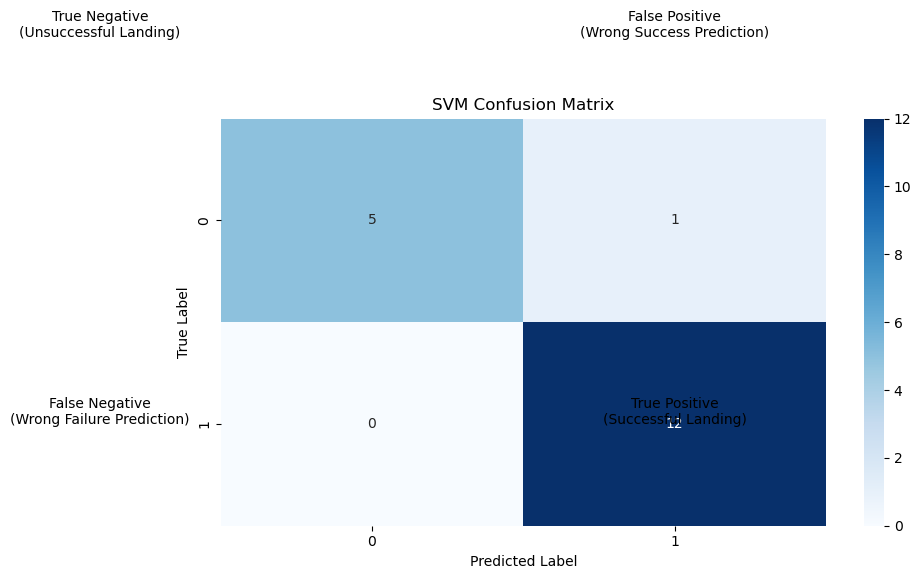


Model Performance Metrics:
Accuracy: 0.944
Precision: 0.923
Recall: 1.000
F1-Score: 0.960

Confusion Matrix Interpretation:
True Negatives (Correctly predicted unsuccessful landings): 5
False Positives (Incorrectly predicted successful landings): 1
False Negatives (Incorrectly predicted unsuccessful landings): 0
True Positives (Correctly predicted successful landings): 12


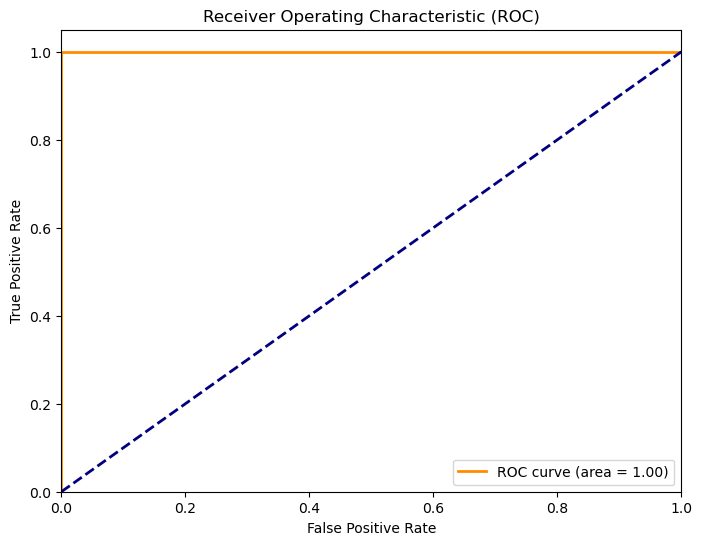

In [2]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Prepare the features (X) and target (y)
X = data.drop('Class', axis=1)
y = data['Class']

# Identify numeric columns
numeric_columns = X.select_dtypes(include=[np.number]).columns

# Handle missing values only for numeric columns
X[numeric_columns] = X[numeric_columns].fillna(X[numeric_columns].mean())

# For categorical columns, fill with mode (most frequent value)
categorical_columns = X.select_dtypes(exclude=[np.number]).columns
for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

# Convert categorical variables to numeric using one-hot encoding
X = pd.get_dummies(X, columns=categorical_columns)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Feature Selection
selector = SelectKBest(f_classif, k=10)  # Select top 10 features
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Get selected feature names
selected_features = X.columns[selector.get_support()].tolist()
print("Selected features:", selected_features)

# Calculate class weights
class_weights = compute_class_weight('balanced', 
                                   classes=np.unique(y_train), 
                                   y=y_train)
weights_dict = dict(zip(np.unique(y_train), class_weights))

# Hyperparameter Tuning with Grid Search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("\nBest parameters:", grid_search.best_params_)
best_svm = grid_search.best_estimator_

# Cross-validation
cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Average CV score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Make predictions with the best model
y_pred_svm = best_svm.predict(X_test_scaled)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations
plt.text(-0.4, -0.4, 'True Negative\n(Unsuccessful Landing)', ha='center')
plt.text(1.5, -0.4, 'False Positive\n(Wrong Success Prediction)', ha='center')
plt.text(-0.4, 1.5, 'False Negative\n(Wrong Failure Prediction)', ha='center')
plt.text(1.5, 1.5, 'True Positive\n(Successful Landing)', ha='center')

plt.tight_layout()
plt.show()

# Calculate and display metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1_score:.3f}")

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (Correctly predicted unsuccessful landings): {tn}")
print(f"False Positives (Incorrectly predicted successful landings): {fp}")
print(f"False Negatives (Incorrectly predicted unsuccessful landings): {fn}")
print(f"True Positives (Correctly predicted successful landings): {tp}")

# Plot ROC Curve
y_pred_proba = best_svm.decision_function(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


In [ ]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Load the data
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")  # Make sure this file exists in your directory

# Prepare the features (X) and target (y)
# Assuming the target column is 'Class' or 'Success' - adjust as needed
X = data.drop('Class', axis=1)  # Replace 'Class' with your target column name
y = data['Class']  # Replace 'Class' with your target column name

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create and train the SVM classifier
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations to explain what each quadrant means
plt.text(-0.4, -0.4, 'True Negative\n(Unsuccessful Landing)', ha='center')
plt.text(1.5, -0.4, 'False Positive\n(Wrong Success Prediction)', ha='center')
plt.text(-0.4, 1.5, 'False Negative\n(Wrong Failure Prediction)', ha='center')
plt.text(1.5, 1.5, 'True Positive\n(Successful Landing)', ha='center')

plt.tight_layout()
plt.show()

# Calculate and display metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1_score:.3f}")

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (Correctly predicted unsuccessful landings): {tn}")
print(f"False Positives (Incorrectly predicted successful landings): {fp}")
print(f"False Negatives (Incorrectly predicted unsuccessful landings): {fn}")
print(f"True Positives (Correctly predicted successful landings): {tp}")


ValueError: could not convert string to float: '2017-05-15'

Loading and preparing data...

Training Logistic Regression...


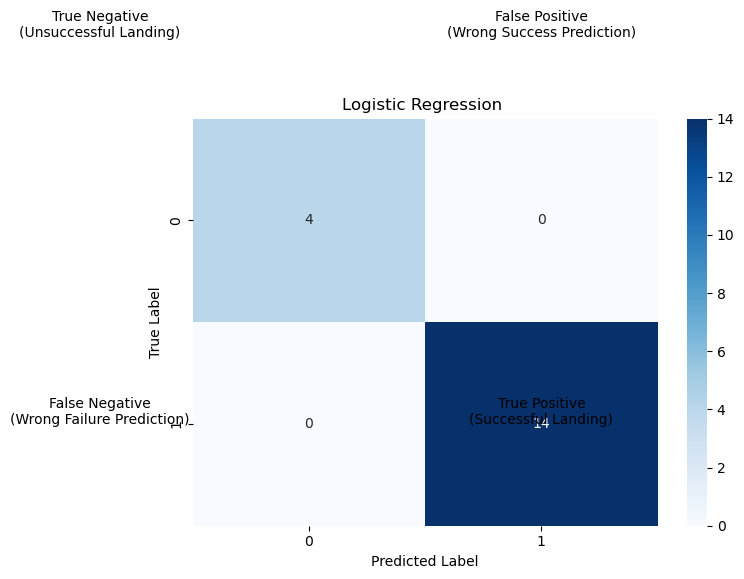


Metrics for Logistic Regression :
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1-Score: 1.000

Confusion Matrix Interpretation:
True Negatives (Correctly predicted unsuccessful landings): 4
False Positives (Incorrectly predicted successful landings): 0
False Negatives (Incorrectly predicted unsuccessful landings): 0
True Positives (Correctly predicted successful landings): 14



Training Decision Tree...


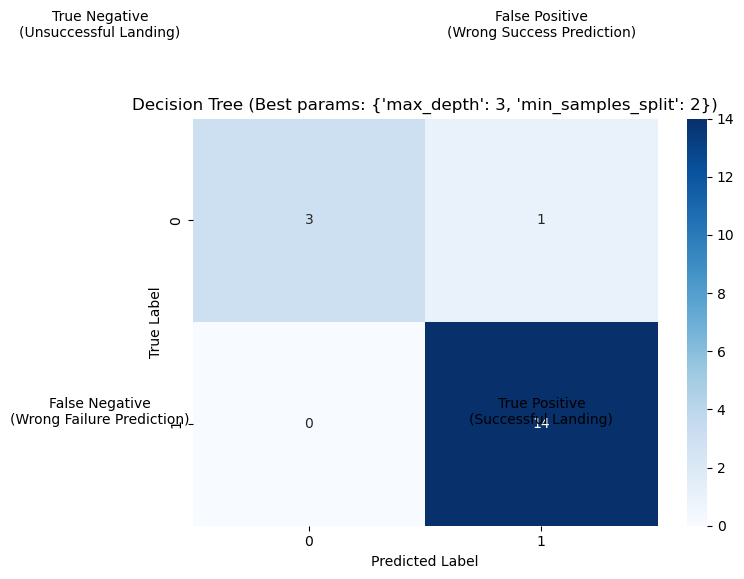


Metrics for Decision Tree (Best params: {'max_depth': 3, 'min_samples_split': 2}):
Accuracy: 0.944
Precision: 0.933
Recall: 1.000
F1-Score: 0.966

Confusion Matrix Interpretation:
True Negatives (Correctly predicted unsuccessful landings): 3
False Positives (Incorrectly predicted successful landings): 1
False Negatives (Incorrectly predicted unsuccessful landings): 0
True Positives (Correctly predicted successful landings): 14



Training Random Forest...


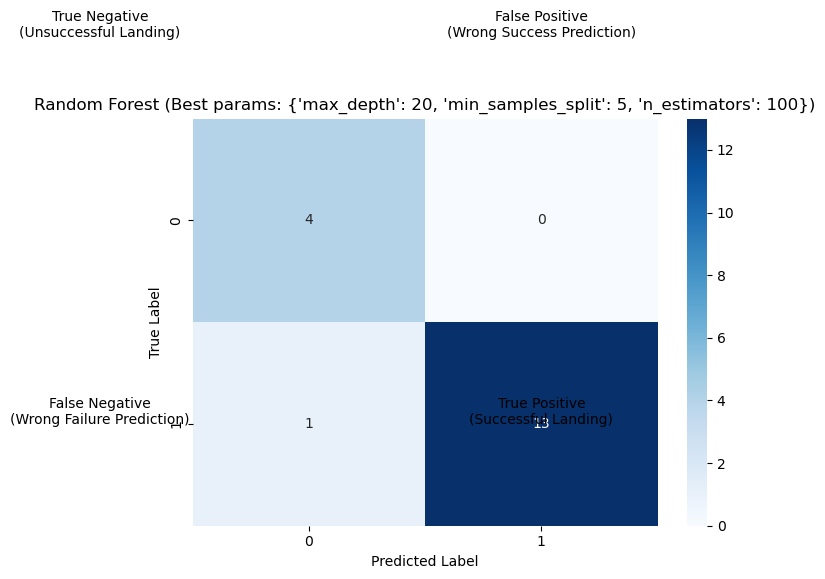


Metrics for Random Forest (Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}):
Accuracy: 0.944
Precision: 1.000
Recall: 0.929
F1-Score: 0.963

Confusion Matrix Interpretation:
True Negatives (Correctly predicted unsuccessful landings): 4
False Positives (Incorrectly predicted successful landings): 0
False Negatives (Incorrectly predicted unsuccessful landings): 1
True Positives (Correctly predicted successful landings): 13



Training KNN...


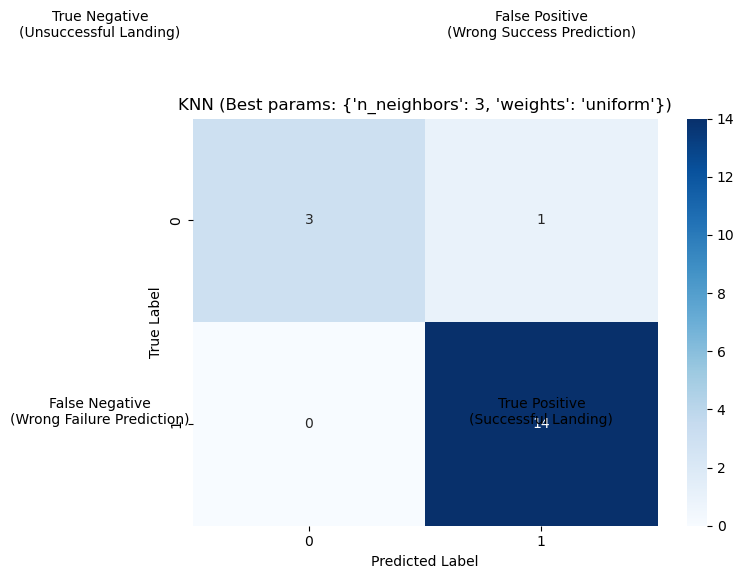


Metrics for KNN (Best params: {'n_neighbors': 3, 'weights': 'uniform'}):
Accuracy: 0.944
Precision: 0.933
Recall: 1.000
F1-Score: 0.966

Confusion Matrix Interpretation:
True Negatives (Correctly predicted unsuccessful landings): 3
False Positives (Incorrectly predicted successful landings): 1
False Negatives (Incorrectly predicted unsuccessful landings): 0
True Positives (Correctly predicted successful landings): 14



Training SVM...


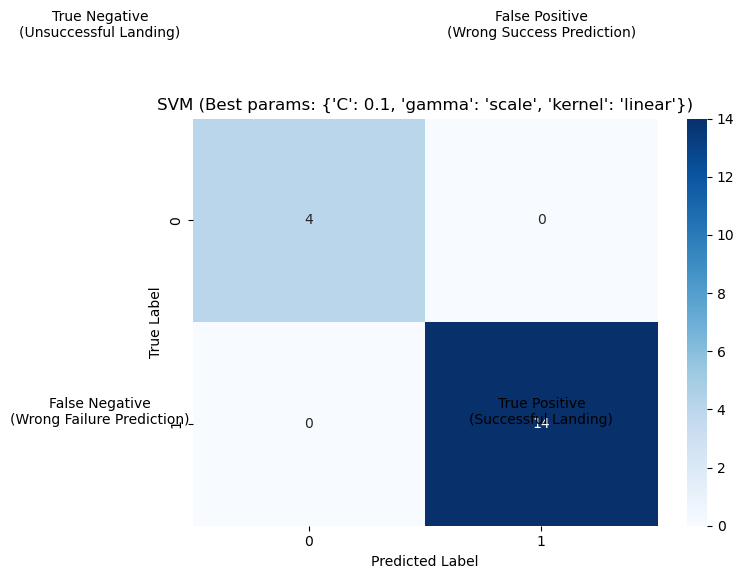


Metrics for SVM (Best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}):
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1-Score: 1.000

Confusion Matrix Interpretation:
True Negatives (Correctly predicted unsuccessful landings): 4
False Positives (Incorrectly predicted successful landings): 0
False Negatives (Incorrectly predicted unsuccessful landings): 0
True Positives (Correctly predicted successful landings): 14



Model Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     1.000      1.000   1.000     1.000
1        Decision Tree     0.944      0.933   1.000     0.966
2        Random Forest     0.944      1.000   0.929     0.963
3                  KNN     0.944      0.933   1.000     0.966
4                  SVM     1.000      1.000   1.000     1.000


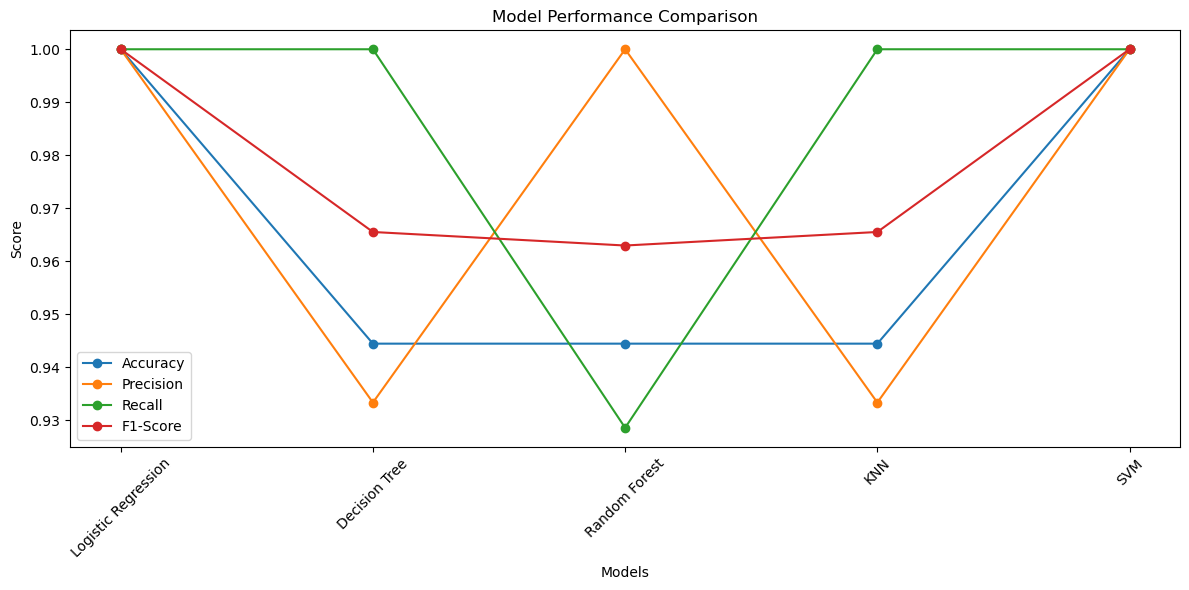


Best performing model: Logistic Regression
Best model parameters: N/A

Example prediction:
Predicted landing outcome: Success


C:\Users\tukue\AppData\Local\Temp\ipykernel_29372\3387505733.py:225: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_data[col] = 0
C:\Users\tukue\AppData\Local\Temp\ipykernel_29372\3387505733.py:225: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_data[col] = 0
C:\Users\tukue\AppData\Local\Temp\ipykernel_29372\3387505733.py:225: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat

: 

In [4]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Import all models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Set random seed for reproducibility
RANDOM_STATE = 42

# Load and prepare the data
print("Loading and preparing data...")
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Prepare features and target
X = data.drop('Class', axis=1)
y = data['Class']

# Handle numeric and categorical columns
numeric_columns = X.select_dtypes(include=[np.number]).columns
X[numeric_columns] = X[numeric_columns].fillna(X[numeric_columns].mean())

categorical_columns = X.select_dtypes(exclude=[np.number]).columns
for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

# Convert categorical variables to numeric
X = pd.get_dummies(X, columns=categorical_columns)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def plot_confusion_matrix(y_true, y_pred, title):
    """
    Function to plot confusion matrix with annotations and calculate metrics
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Add text annotations
    plt.text(-0.4, -0.4, 'True Negative\n(Unsuccessful Landing)', ha='center')
    plt.text(1.5, -0.4, 'False Positive\n(Wrong Success Prediction)', ha='center')
    plt.text(-0.4, 1.5, 'False Negative\n(Wrong Failure Prediction)', ha='center')
    plt.text(1.5, 1.5, 'True Positive\n(Successful Landing)', ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\nMetrics for {title}:")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    
    tn, fp, fn, tp = cm.ravel()
    print("\nConfusion Matrix Interpretation:")
    print(f"True Negatives (Correctly predicted unsuccessful landings): {tn}")
    print(f"False Positives (Incorrectly predicted successful landings): {fp}")
    print(f"False Negatives (Incorrectly predicted unsuccessful landings): {fn}")
    print(f"True Positives (Correctly predicted successful landings): {tp}")
    print("\n" + "="*50 + "\n")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Dictionary to store all models and their parameters
models = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        'params': {}
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'params': {
            'max_depth': [3, 5, 7, 10],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance']
        }
    },
    'SVM': {
        'model': SVC(random_state=RANDOM_STATE),
        'params': {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 'auto', 0.1],
            'kernel': ['rbf', 'linear']
        }
    }
}

# Train models and store results
results = []
trained_models = {}

for name, model_info in models.items():
    print(f"\nTraining {name}...")
    
    if model_info['params']:
        # Use GridSearchCV if parameters are provided
        model = GridSearchCV(model_info['model'], 
                           model_info['params'], 
                           cv=5, 
                           n_jobs=-1)
    else:
        # Use the model directly if no parameters
        model = model_info['model']
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Store the trained model
    trained_models[name] = model
    
    # Plot confusion matrix and get metrics
    metrics = plot_confusion_matrix(y_test, y_pred, 
                                  f"{name} " + (f"(Best params: {model.best_params_})" 
                                              if hasattr(model, 'best_params_') else ""))
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1']
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(comparison_df.round(3))

# Plot model comparison
plt.figure(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for metric in metrics:
    plt.plot(comparison_df['Model'], comparison_df[metric], marker='o', label=metric)

plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Find the best model based on F1-Score
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
best_model = trained_models[best_model_name]

print(f"\nBest performing model: {best_model_name}")
print(f"Best model parameters: {best_model.best_params_ if hasattr(best_model, 'best_params_') else 'N/A'}")

# Save the best model
import joblib
joblib.dump(best_model, 'best_spacex_landing_model.joblib')
joblib.dump(scaler, 'spacex_scaler.joblib')

# Function to make predictions with the best model
def predict_landing_success(new_data):
    """
    Make predictions using the best model
    
    Parameters:
    new_data: DataFrame containing the same features as training data
    """
    # Ensure the data has the same features
    numeric_columns = new_data.select_dtypes(include=[np.number]).columns
    categorical_columns = new_data.select_dtypes(exclude=[np.number]).columns
    
    # Handle missing values
    new_data[numeric_columns] = new_data[numeric_columns].fillna(new_data[numeric_columns].mean())
    for col in categorical_columns:
        new_data[col] = new_data[col].fillna(new_data[col].mode()[0])
    
    # One-hot encoding
    new_data = pd.get_dummies(new_data, columns=categorical_columns)
    
    # Ensure all columns from training are present
    for col in X.columns:
        if col not in new_data.columns:
            new_data[col] = 0
    
    # Keep only columns that were in training data
    new_data = new_data[X.columns]
    
    # Scale the features
    new_data_scaled = scaler.transform(new_data)
    
    # Make prediction
    prediction = best_model.predict(new_data_scaled)
    
    return "Success" if prediction[0] == 1 else "Failure"

# Example usage of the prediction function
print("\nExample prediction:")
example_data = pd.DataFrame({
    'FlightNumber': [100],
    'PayloadMass': [5000],
    'Orbit': ['LEO'],
    'LaunchSite': ['KSC LC-39A'],
    'Flights': [1],
    'GridFins': [True],
    'Reused': [False],
    'Legs': [True],
    'Block': [5],
    'ReusedCount': [0],
    'Serial': ['B1058'],
    'Longitude': [-80.6039],
    'Latitude': [28.6080]
})

prediction = predict_landing_success(example_data)
print(f"Predicted landing outcome: {prediction}")


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork865-2023-01-01)


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
